In [2]:
import pandas as pd
# 再次載入上傳的 Sanyi 數據
data = pd.read_csv('SanYi_training.csv')

# 檢查數據的基本結構與內容
data.info(), data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43752 entries, 0 to 43751
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PM25        43752 non-null  int64  
 1   PM10        43747 non-null  float64
 2   CO          43752 non-null  float64
 3   NO          43752 non-null  float64
 4   NO2         43752 non-null  float64
 5   NOx         43752 non-null  float64
 6   O3          43752 non-null  float64
 7   PH_RAIN     43752 non-null  float64
 8   RAINFALL    43752 non-null  float64
 9   RH          43752 non-null  float64
 10  SO2         43752 non-null  float64
 11  TEMP        43752 non-null  float64
 12  UVB         43752 non-null  float64
 13  WIND_DIREC  43752 non-null  float64
 14  WIND_SPEED  43752 non-null  float64
dtypes: float64(14), int64(1)
memory usage: 5.0 MB


(None,
    PM25  PM10    CO    NO    NO2    NOx    O3  PH_RAIN  RAINFALL     RH  SO2  \
 0    20  35.0  0.12  1.21  13.27  14.48  22.8      0.0       0.0  90.51  1.5   
 1    16  28.0  0.11  0.98   9.17  10.15  25.7      0.0       0.0  90.25  1.4   
 2    16  26.0  0.33  0.78   7.98   8.76  26.9      0.0       0.0  90.24  1.5   
 3    15  33.0  0.32  1.08  10.51  11.58  25.4      0.0       0.0  90.41  2.3   
 4    13  30.0  0.32  1.07  15.44  16.51  16.4      0.0       0.0  91.48  2.4   
 
     TEMP  UVB  WIND_DIREC  WIND_SPEED  
 0  14.77  0.0       33.16        4.24  
 1  14.91  0.0       30.16        4.36  
 2  15.03  0.0       35.15        4.27  
 3  14.95  0.0       35.30        4.01  
 4  14.72  0.0       34.57        4.13  )

In [3]:
# 描述性統計
print(data.describe())



               PM25          PM10            CO            NO           NO2  \
count  43752.000000  43747.000000  43752.000000  43752.000000  43752.000000   
mean      27.431249     47.445685      0.319926      2.028926     11.632555   
std       19.120461     31.120988      0.140045      2.903157      6.397724   
min        0.000000      0.000000      0.050000     -0.290000      0.150000   
25%       13.000000     26.000000      0.220000      0.710000      7.120000   
50%       23.000000     42.000000      0.300000      1.250000     10.430000   
75%       38.000000     62.000000      0.400000      2.170000     14.800000   
max      240.000000    694.000000      1.320000     64.090000     63.550000   

                NOx            O3       PH_RAIN      RAINFALL            RH  \
count  43752.000000  43752.000000  43752.000000  43752.000000  43752.000000   
mean      13.668853     32.940491      0.286560      0.282762     81.311551   
std        7.995039     19.520381      1.139614    

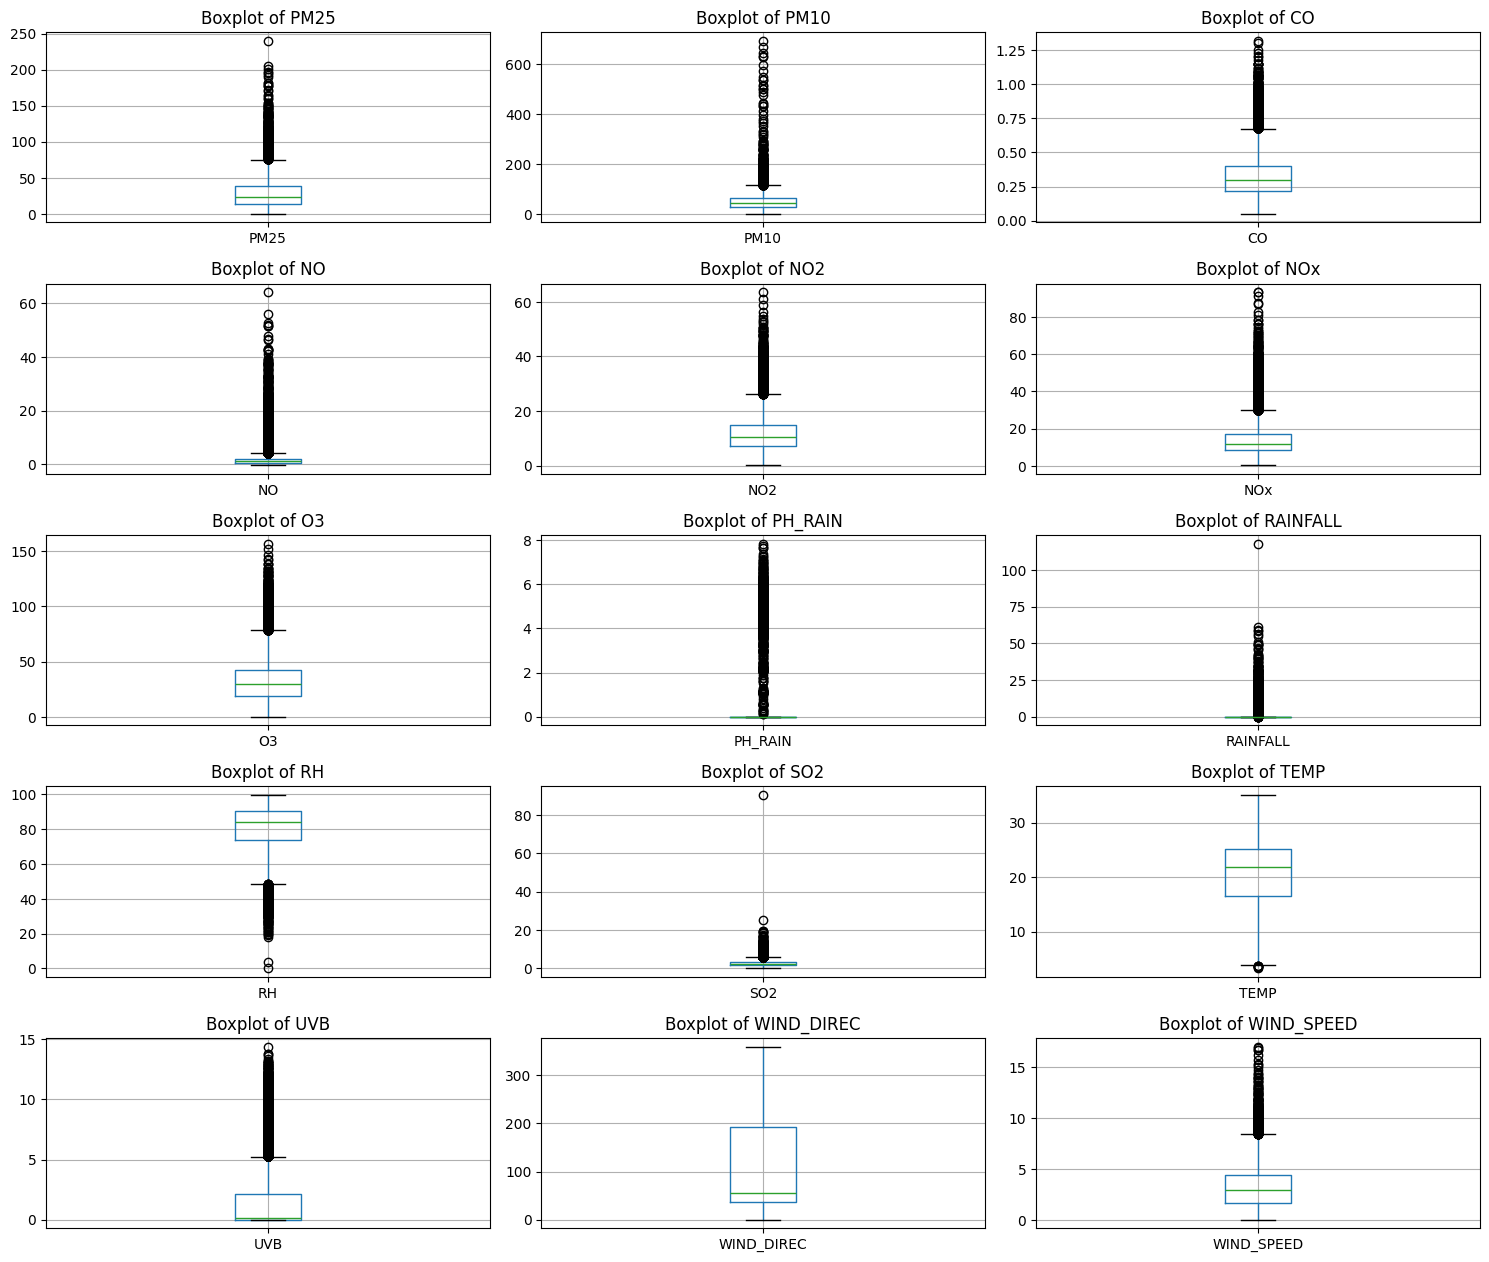

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 選擇數值型變數
numeric_data = data.select_dtypes(include='number')

# 繪製每個數值變數的盒鬚圖
fig, axes = plt.subplots(len(numeric_data.columns)//3 + 1, 3, figsize=(15, 15))
axes = axes.flatten()

for i, column in enumerate(numeric_data.columns):
    numeric_data.boxplot(column=column, ax=axes[i])
    axes[i].set_title(f'Boxplot of {column}')

# 移除多餘的子圖框架
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43747 entries, 0 to 43746
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PM25        43747 non-null  int64  
 1   PM10        43747 non-null  float64
 2   CO          43747 non-null  float64
 3   NO          43747 non-null  float64
 4   NO2         43747 non-null  float64
 5   NOx         43747 non-null  float64
 6   O3          43747 non-null  float64
 7   PH_RAIN     43747 non-null  float64
 8   RAINFALL    43747 non-null  float64
 9   RH          43747 non-null  float64
 10  SO2         43747 non-null  float64
 11  TEMP        43747 non-null  float64
 12  UVB         43747 non-null  float64
 13  WIND_DIREC  43747 non-null  float64
 14  WIND_SPEED  43747 non-null  float64
dtypes: float64(14), int64(1)
memory usage: 5.3 MB


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 丟棄缺失值
data_cleaned = data.dropna()

# 處理極端值：使用IQR方法去除極端值
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# 對所有數值欄位進行極端值處理
data_no_outliers = data_cleaned.copy()
for column in data_no_outliers.columns:
    data_no_outliers = remove_outliers(data_no_outliers, column)

# 確認剩餘的數據筆數
data_no_outliers.shape


(25753, 15)

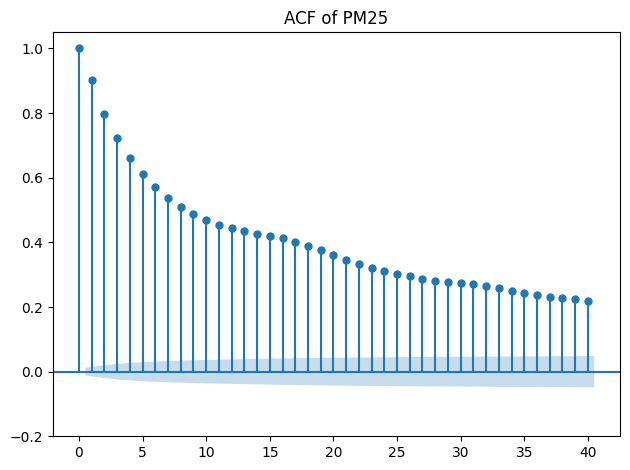

In [7]:
# 再次嘗試繪製 ACF 和 PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 繪製 ACF
plot_acf(data_no_outliers['PM25'], lags=40)
plt.title('ACF of PM25')
plt.ylim(-.2, 1.05)
plt.tight_layout()
plt.show()


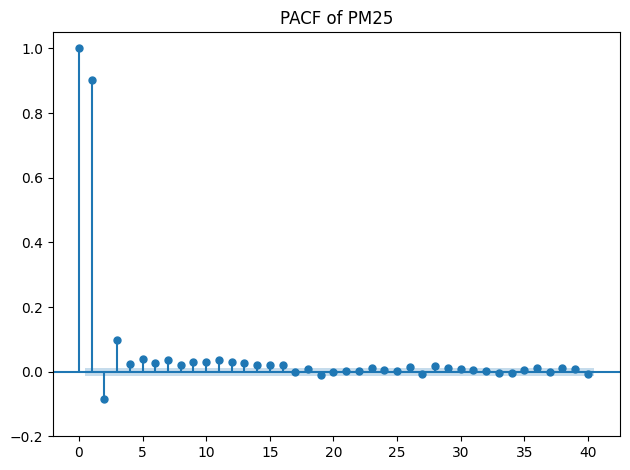

In [8]:
# 再次嘗試繪製 ACF 和 PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 繪製 PACF
plot_pacf(data_no_outliers['PM25'], lags=40)
plt.title('PACF of PM25')
plt.ylim(-.2, 1.05)

plt.tight_layout()
plt.show()


In [9]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 對 PM25 進行一次差分
data_no_outliers['PM25_diff'] = data_no_outliers['PM25'].diff().dropna()

# 檢查一次差分後的平穩性 (ADF 檢定)
# adf_test_diff = adfuller(data_no_outliers['PM25_diff'].dropna())

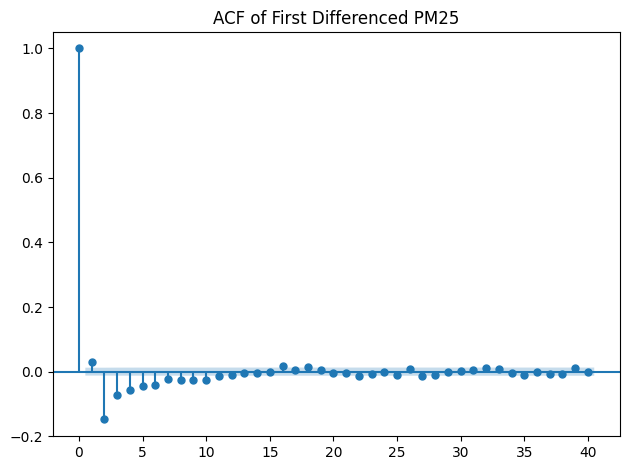

In [10]:
# ACF
plot_acf(data_no_outliers['PM25_diff'].dropna(), lags=40)
plt.ylim(-.2, 1.05)

plt.title('ACF of First Differenced PM25')

plt.tight_layout()
plt.show()

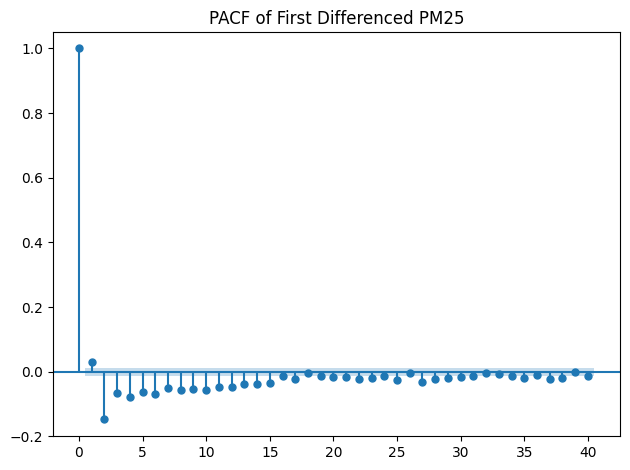

In [11]:
# PACF
plot_pacf(data_no_outliers['PM25_diff'].dropna(), lags=40)
plt.title('PACF of First Differenced PM25')
plt.ylim(-.2, 1.05)

plt.tight_layout()
plt.show()

In [12]:

# 返回 ADF 檢定結果
adf_results_diff = {
    'Test Statistic': adf_test_diff[0],
    'p-value': adf_test_diff[1],
    'Critical Values': adf_test_diff[4]
}
adf_results_diff


NameError: name 'adf_test_diff' is not defined

In [13]:
from statsmodels.tsa.arima.model import ARIMA

# 訓練 ARIMA(1,1,1) 模型
model_111 = ARIMA(data_no_outliers['PM25'], order=(1, 1, 1))
results_111 = model_111.fit()

# 獲取模型摘要
model_summary = results_111.summary()

# 顯示模型摘要
model_summary


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   PM25   No. Observations:                25753
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -85211.116
Date:                Thu, 26 Dec 2024   AIC                         170428.231
Time:                        00:32:46   BIC                         170452.700
Sample:                             0   HQIC                        170436.140
                              - 25753                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8707      0.003    255.688      0.000       0.864       0.877
ma.L1         -0.9876      0.001   -845.876      0.000      -0.990      -0.985
sigma2        43.8117      0.182    241.035      0.000      43.455      44.168
===================================================================================
Ljung-Box (L1) (Q):                 202.63   Jarque-Bera (JB):             88151.49
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.75
Prob(H) (two-sided):                  0.61   Kurtosis:                        11.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

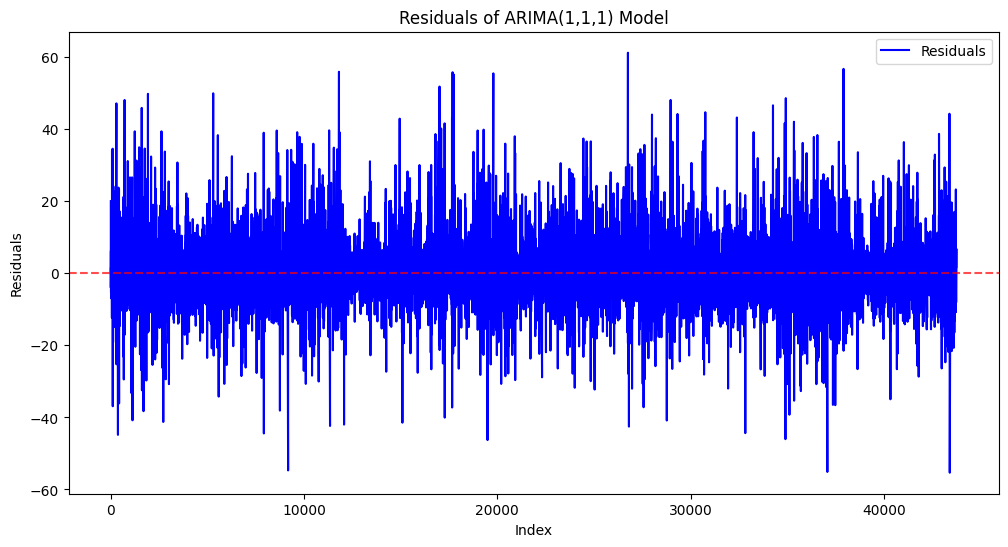

In [14]:
import matplotlib.pyplot as plt

# 繪製 ARIMA(1,1,1) 模型的殘差
residuals = results_111.resid

plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.axhline(y=0, linestyle='--', color='red', alpha=0.7)
plt.title('Residuals of ARIMA(1,1,1) Model')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.legend()
plt.show()


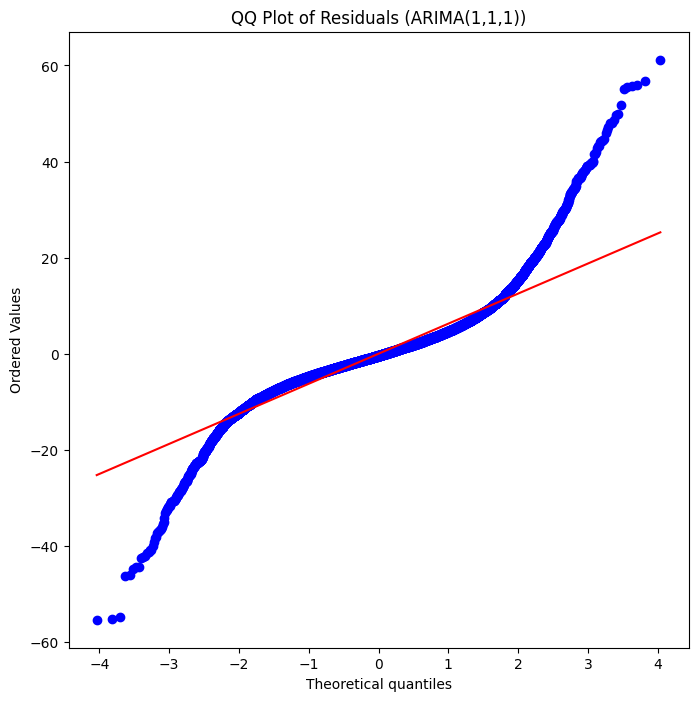

In [15]:
import scipy.stats as stats

# 繪製殘差的 QQ plot
residuals = results_111.resid

plt.figure(figsize=(8, 8))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals (ARIMA(1,1,1))")
plt.show()


In [16]:
corr_matrix = data_no_outliers.corr()
m = pd.DataFrame(corr_matrix['PM25'].sort_values(ascending=False))
m

,PM25
PM25,1.000000
PM10,0.714395
CO,0.484820
O3,0.311591
SO2,0.302043
NO2,0.290409
NOx,0.269092
PM25_diff,0.220961
UVB,0.018203
TEMP,-0.023589


In [17]:
from statsmodels.tsa.arima.model import ARIMA

# 準備外生變數
exog_variables = ['PM10', 'CO', 'O3', 'SO2', 'NO2', 'NOx']
data_no_outliers_exog = data_no_outliers[exog_variables].dropna()  # 確保外生變數無缺失值
data_no_outliers_target = data_no_outliers['PM25'][data_no_outliers_exog.index]  # 同步目標變數

# 構建 ARIMAX 模型 (1,1,1) + 外生變數
arimax_model = ARIMA(endog=data_no_outliers_target, exog=data_no_outliers_exog, order=(1, 1, 1))
arimax_results = arimax_model.fit()

# 顯示模型摘要
arimax_summary = arimax_results.summary()
arimax_summary


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   PM25   No. Observations:                25753
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -80741.329
Date:                Thu, 26 Dec 2024   AIC                         161500.658
Time:                        00:33:09   BIC                         161574.065
Sample:                             0   HQIC                        161524.384
                              - 25753                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PM10           0.3578      0.002    158.637      0.000       0.353       0.362
CO             9.2578      0.595     15.549      0.000       8.091      10.425
O3             0.0562      0.003     19.194      0.000       0.050       0.062
SO2           -0.2843      0.046     -6.195      0.000      -0.374      -0.194
NO2            0.1064      0.027      3.939      0.000       0.053       0.159
NOx           -0.0499      0.025     -1.984      0.047      -0.099      -0.001
ar.L1          0.8524      0.003    329.570      0.000       0.847       0.857
ma.L1         -0.9968      0.001  -1943.945      0.000      -0.998      -0.996
sigma2        30.9605      0.127    244.176      0.000      30.712      31.209
===================================================================================
Ljung-Box (L1) (Q):                 142.27   Jarque-Bera (JB):            112464.11
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.34   Skew:                             0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

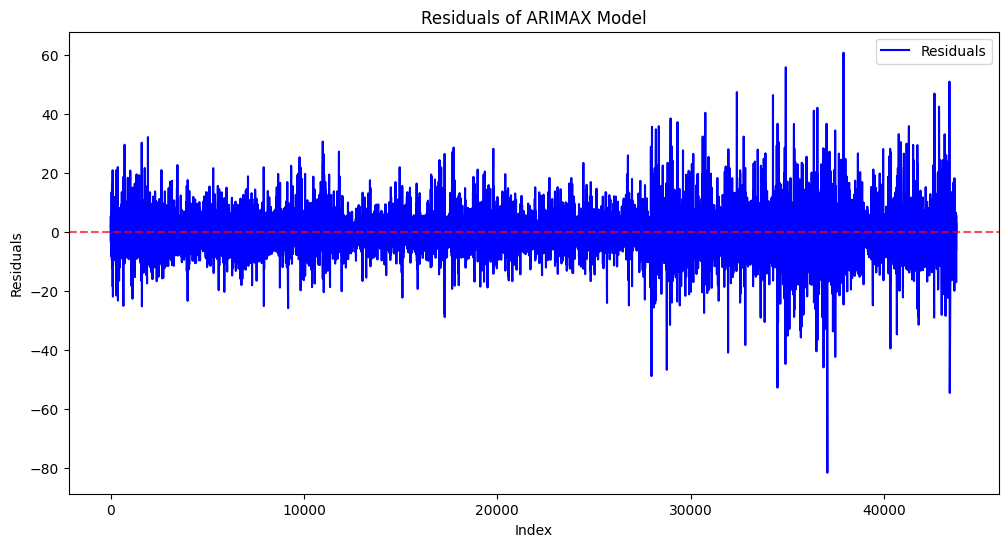

In [19]:
import matplotlib.pyplot as plt

# 獲取實際值和模型的擬合值
fitted_values = arimax_results.predict(start=0, end=len(data_no_outliers_target)-1, exog=data_no_outliers_exog)
residuals = data_no_outliers_target - fitted_values

# 繪製殘差時間序列圖
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.axhline(y=0, linestyle='--', color='red', alpha=0.7)
plt.title('Residuals of ARIMAX Model')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.legend()
plt.show()
